# 1. モジュールインポート

In [1]:
import pandas as pd
import numpy as np
import os
import optuna.integration.lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
import joblib
from tqdm.auto import tqdm
from modules.constants._master import Master
from modules.constants._local_paths import LocalPaths
from modules.preprocessing._create_population import CreatePopulationProcessor
from modules.preprocessing._feature_engineering import FeatureEngineering
from modules.preprocessing._horse_results_processor import HorseResultsProcessor
from modules.preprocessing._weather_processor import WeatherResultsProcessor
from modules.preprocessing._supporter_processor import SupporterProcessor
from modules.preprocessing._horse_train_processor import HorseTrainProcessor
from modules.preprocessing._jrdb_processor import JrDbProcessor
from modules.preprocessing._return_processor import ReturnProcessor
from modules.preprocessing._speed_index_processor import SpeedIndexProcessor
from modules.preprocessing._shutsuba_processor import ShutsubaProcessor
from modules.preprocessing._data_merger import DataMerger
from modules.training._create_model import CreateModel
from modules.training._keiba_ai_factory import KeibaAIFactory
from modules.training._post_note_x import PostNoteX
from modules.training._train_keras import TrainKeras
from IPython.display import display
%load_ext autoreload

pd.set_option('display.max_columns', 200)

In [ ]:
from importlib import reload
from modules.preprocessing import _jrdb_processor
reload(_jrdb_processor)

In [28]:
import gc
%reload_ext autoreload
gc.collect()

44218

# 2. データを取得

## 2.1. JRDBのデータを取得

In [2]:
# IDM指数
idm_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\IDM', ['race_id_horse','idm_index'], float)
# 騎手指数
jockey_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\JOCKEY', ['race_id_horse','jockey_index'], float)
# 情報指数
info_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\INFORMATION', ['race_id_horse','info_index'], float)
# 総合指数
total_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\TOTAL', ['race_id_horse','toral_index'], float)
# 人気指数
popular_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\POPULAR', ['race_id_horse','popular_index'], float)
# 調教指数
train_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\TRAINING', ['race_id_horse','train_index'], float)
# 厩舎指数
stable_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\STABLE', ['race_id_horse','stable_index'], float)
# 激走指数
gekiso_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\GEKISO', ['race_id_horse','gekiso_index'], float)
# テン指数
ten_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\FIRST', ['race_id_horse','ten_index','ten_rank'], float)
# ペース指数
pace_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\PACE', ['race_id_horse','pace_index','pace_rank'], float)
# 上り指数
agari_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\LAST', ['race_id_horse','last_index','last_rank'], float)
# 位置指数
position_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\POSITION', ['race_id_horse','position_index','position_rank'], float)
# 万券指数
manken_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\MANKEN', ['race_id_horse','manken_index'], float)
# 馬スタート指数
start_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\KY\HORSESTART', ['race_id_horse','start_index'], float)
# 追切指数
oikiri_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\CY\OIKIRI', ['race_id_horse','oikiri_index'], float)
# 仕上がり指数
shiagari_index_df = JrDbProcessor.load_and_combine_csv(r'C:\TFJV\MY_DATA\JRDB\CY\SHIAGARI', ['race_id_horse','shiagari_index'], float)
# 外厩
gaikyu_df = JrDbProcessor.load_gaikyu_csv(r'C:\TFJV\TXT\gaikyu')

## 2.2. TARGETのデータを取得

In [173]:
%autoreload

In [3]:
results_df, horse_results_df = HorseResultsProcessor._preprocess(LocalPaths.TARGET_HORSE_RESULTS_PATH)
jockey_df = SupporterProcessor._preprocess(folder_path=LocalPaths.JOCKEY_DIR,
    kind="jockey")
trainer_df = SupporterProcessor._preprocess(folder_path=LocalPaths.TRAINER_DIR,
    kind="trainer")
sir_df = SupporterProcessor._preprocess(folder_path=LocalPaths.SIR_DIR,
    kind="sir")
bms_df = SupporterProcessor._preprocess(folder_path=LocalPaths.BMS_DIR,
    kind="bms")
train_hanro_df = HorseTrainProcessor._preprocess_hanro(LocalPaths.TARGET_TRAIN_HANRO_PATH)
train_wood_df = HorseTrainProcessor._preprocess_wood(LocalPaths.TARGET_TRAIN_WOOD_PATH)
return_df =ReturnProcessor._preprocess(LocalPaths.TARGET_RETURN_PATH)

In [4]:
# JRDBのデータを結合
results_df = results_df.merge(
    idm_index_df,on=['race_id_horse'],how="left").merge(
    jockey_index_df,on=['race_id_horse'],how="left").merge(
    info_index_df,on=['race_id_horse'],how="left").merge(
    total_index_df,on=['race_id_horse'],how="left").merge(
    popular_index_df,on=['race_id_horse'],how="left").merge(
    stable_index_df,on=['race_id_horse'],how="left").merge(
    gekiso_index_df,on=['race_id_horse'],how="left").merge(
    ten_index_df,on=['race_id_horse'],how="left").merge(
    pace_index_df,on=['race_id_horse'],how="left").merge(
    agari_index_df,on=['race_id_horse'],how="left").merge(
    position_index_df,on=['race_id_horse'],how="left").merge(
    manken_index_df,on=['race_id_horse'],how="left").merge(
    start_index_df,on=['race_id_horse'],how="left").merge(
    oikiri_index_df,on=['race_id_horse'],how="left").merge(
    shiagari_index_df,on=['race_id_horse'],how="left").merge(
    gaikyu_df,on=['race_id_horse'],how="left")

In [5]:
#スピード、上り指数、3ハロン前タイム指数を作成

# SpeedIndexProcessor.calc_standard_time(horse_results_df, "time")
# SpeedIndexProcessor.calc_course_len_index("time")
# SpeedIndexProcessor.calc_class_index(horse_results_df, "time")
SpeedIndexProcessor.calc_ground_index(horse_results_df, "time")
speed_index_processor = SpeedIndexProcessor.calc_speed_index(results_df, horse_results_df, "time")

# SpeedIndexProcessor.calc_standard_time(horse_results_df, "agari")
# SpeedIndexProcessor.calc_course_len_index("agari")
# SpeedIndexProcessor.calc_class_index(horse_results_df, "agari")
SpeedIndexProcessor.calc_ground_index(horse_results_df, "agari")
agari_index_processor = SpeedIndexProcessor.calc_speed_index(results_df, horse_results_df, "agari")

# SpeedIndexProcessor.calc_standard_time(horse_results_df, "ten_3f_time")
# SpeedIndexProcessor.calc_course_len_index("ten_3f_time")
# SpeedIndexProcessor.calc_class_index(horse_results_df, "ten_3f_time")
SpeedIndexProcessor.calc_ground_index(horse_results_df, "ten_3f_time")
ten_3f_time_index_processor = SpeedIndexProcessor.calc_speed_index(results_df, horse_results_df, "ten_3f_time")


## 2.3. 天候データを取得

In [6]:
weather_df = WeatherResultsProcessor._preprocess()

# 3. データ加工

In [81]:
%autoreload

In [7]:
# 学習母集団の作成
population_df = CreatePopulationProcessor._preprocess(
    file_path=LocalPaths.POPULATION_PATH,
    from_date="2018-01-01",
    to_date="2024-12-31")

In [ ]:
# 馬の過去成績を集計しつつ、前処理の済みの全てのテーブルをマージする
data_merger = DataMerger(
    population_df,
    results_df,
    horse_results_df,
    jockey_df,
    trainer_df,
    sir_df,
    bms_df,
    train_hanro_df,
    train_wood_df,
    speed_index_processor,
    agari_index_processor,
    ten_3f_time_index_processor,
    weather_df,
    Master.TARGET_COLS_MEAN,
    Master.TARGET_COLS_MAX,
    Master.TARGET_COLS_MIN,
    Master.TARGET_COLS_SIZE,
    Master.GROUP_COLS
)

# mergeメソッドを呼び出す
merged_df = data_merger.merge()

# CSVファイルで保存
MERGED_PATH: str = os.path.join(
    LocalPaths.TMP_DIR, "merged_df.csv"
)
merged_df._population_df.to_csv(MERGED_PATH, index=False)

In [ ]:
# 特徴量のマージ結果をcsvファイルより読み込む
MERGED_PATH: str = os.path.join(
    LocalPaths.TMP_DIR, "merged_df.csv"
)
merged_df = pd.read_csv(MERGED_PATH, dtype={
    'race_id_new': 'object', 'race_type': 'object',
    'hanro_train_kaisai': 'object', 'hanro_day_of_week': 'object', 'train_hanro': 'int32',
    'wood_train_kaisai': 'object', 'wood_train_course': 'object', 'wood_train_around': 'object', 
    'wood_day_of_week': 'object', 'train_wood': 'int32', 'race_id_horse': 'object', 
    'kaisai': 'object',  'ground_state': 'object', 'sex': 'object', 'box_category': 'object',
    'blinker': 'object', 'leg_quality_1R_mode': 'object', 'leg_quality_3R_mode': 'object',
    'leg_quality_5R_mode': 'object', 'leg_quality_8R_mode': 'object', 'gear': 'object', 'leg_quality': 'object',
    })
merged_df['date'] = pd.to_datetime(merged_df['date'], format='%Y-%m-%d')
merged_df['latest'] = pd.to_datetime(merged_df['latest'], format='%Y-%m-%d')

In [10]:
copy_df = data_merger._population_df.copy()
# 芝レースのみを学習対象にする
data_merger._population_df = copy_df[copy_df["race_type"] == "00"]

In [ ]:
# 各特徴量のワンホットエンコーディングを行う。
feature_enginnering = FeatureEngineering(merged_df._population_df)\
    .encode_race_type()\
    .encode_sex()\
    .encode_umaban()\
    .encode_in_out()\
    .encode_ground_state()\
    .encode_wakuban()\
    .encode_kaisai()\
    .encode_blinker()\
    .encode_n_horses()\
    .encode_box_category()\
    .encode_weather()\
    .encode_train_course()\
    .encode_class()\
    .other_leg_quality()\
    .encode_leg_quality()\
    .encode_gear()\
    .encode_course_len()\
    .encode_dtype()
feature_enginnering.featured_data["leg_quality"] = feature_enginnering.featured_data["leg_quality"].astype(float)

In [12]:
# 特徴量の全カラムをyamlに保存
feature_cols = {'features': feature_enginnering.featured_data.columns.drop(
    ['date', 'rank',"race_id_horse","race_id_new", 'horse_name', 'odds', 'populality', 'trainer_name',
      'owner_name', 'jockey_name', "latest"]).to_list()}
with open('config_all.yaml', "w", encoding='utf-8') as file:
    yaml.dump(feature_cols, file, allow_unicode=True)

# 4. 学習

In [22]:
%autoreload

In [13]:
# データを学習用、訓練用、検証用に分ける。また、特徴量のカラム名を取得
train_df, valid_df, test_df = CreateModel.dataSplit(feature_enginnering)

全体のデータ数: 86172
学習 + 検証データ数: 61648
学習データ数: 43547
検証データ数: 18101
テストデータ数: 22425


In [ ]:
#回帰モデルで利用する特徴量を取得
with open('config_time.yaml', 'r', encoding='utf-8') as file:
    data = yaml.safe_load(file)
feature_cols = data.get('features')

# Kerasで学習する
target_columns = ["time", "agari","pci","first_corner_score",
    "final_corner_score", "third_corner_score", "leg_quality",
    "ten_3f_time", "ave_1f_time", "correction_2", "time_index", "agari_index"]

# 目的値ごとに学習し、モデルを保存する。
for target in target_columns:
    # モデルを訓練
    model_pred = TrainKeras.train_keras_kaiki(train_df, valid_df, feature_cols, target)

    # モデルを保存
    version_name = f'20250927_turf_{target}'
    KeibaAIFactory.save(model_pred, version_name=version_name)

In [ ]:
# 学習済みの回帰モデルの予測結果を学習データ、テストデータに追加
with open('config_time.yaml', 'r', encoding='utf-8') as file:
    data = yaml.safe_load(file)
feature_cols = data.get('features')
model_time = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_time.h5')
model_agari = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_agari.h5')
model_pci = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_pci.h5')
model_first = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_first_corner_score.h5')
model_third = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_third_corner_score.h5')
model_final = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_final_corner_score.h5')
model_ten_3f = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_ten_3f_time.h5')
model_ave_1f = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_ave_1f_time.h5')
model_leg = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_leg_quality.h5')
model_correction_2 = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_correction_2.h5')
model_speed_index = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_time_index.h5')
model_agari_index = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_agari_index.h5')
train_df["time_pred"] = model_time.predict(train_df[feature_cols])
train_df["agari_pred"] = model_agari.predict(train_df[feature_cols])
train_df["pci_pred"] = model_pci.predict(train_df[feature_cols])
train_df["first_corner_score_pred"] = model_first.predict(train_df[feature_cols])
train_df["third_corner_score_pred"] = model_third.predict(train_df[feature_cols])
train_df["final_corner_score_pred"] = model_final.predict(train_df[feature_cols])
train_df["ten_3f_time_pred"] = model_ten_3f.predict(train_df[feature_cols])
train_df["ave_1f_time_pred"] = model_ave_1f.predict(train_df[feature_cols])
train_df["leg_quality_pred"] = model_leg.predict(train_df[feature_cols])
train_df["correction_2_pred"] = model_correction_2.predict(train_df[feature_cols])
train_df["time_index_pred"] = model_speed_index.predict(train_df[feature_cols])
train_df["agari_index_pred"] = model_agari_index.predict(train_df[feature_cols])
valid_df["time_pred"] = model_time.predict(valid_df[feature_cols])
valid_df["agari_pred"] = model_agari.predict(valid_df[feature_cols])
valid_df["pci_pred"] = model_pci.predict(valid_df[feature_cols])
valid_df["first_corner_score_pred"] = model_first.predict(valid_df[feature_cols])
valid_df["third_corner_score_pred"] = model_third.predict(valid_df[feature_cols])
valid_df["final_corner_score_pred"] = model_final.predict(valid_df[feature_cols])
valid_df["ten_3f_time_pred"] = model_ten_3f.predict(valid_df[feature_cols])
valid_df["ave_1f_time_pred"] = model_ave_1f.predict(valid_df[feature_cols])
valid_df["leg_quality_pred"] = model_leg.predict(valid_df[feature_cols])
valid_df["correction_2_pred"] = model_correction_2.predict(valid_df[feature_cols])
valid_df["time_index_pred"] = model_speed_index.predict(valid_df[feature_cols])
valid_df["agari_index_pred"] = model_agari_index.predict(valid_df[feature_cols])
test_df["time_pred"] = model_time.predict(test_df[feature_cols])
test_df["agari_pred"] = model_agari.predict(test_df[feature_cols])
test_df["pci_pred"] = model_pci.predict(test_df[feature_cols])
test_df["first_corner_score_pred"] = model_first.predict(test_df[feature_cols])
test_df["third_corner_score_pred"] = model_third.predict(test_df[feature_cols])
test_df["final_corner_score_pred"] = model_final.predict(test_df[feature_cols])
test_df["ten_3f_time_pred"] = model_ten_3f.predict(test_df[feature_cols])
test_df["ave_1f_time_pred"] = model_ave_1f.predict(test_df[feature_cols])
test_df["leg_quality_pred"] = model_leg.predict(test_df[feature_cols])
test_df["correction_2_pred"] = model_correction_2.predict(test_df[feature_cols])
test_df["time_index_pred"] = model_speed_index.predict(test_df[feature_cols])
test_df["agari_index_pred"] = model_agari_index.predict(test_df[feature_cols])

In [ ]:
# 学習で利用する特徴量を取得
with open('config.yaml', 'r', encoding='utf-8') as file:
    data = yaml.safe_load(file)
feature_cols = data.get('features')

# kerasで学習する
model = TrainKeras.train_keras_ranking(train_df, valid_df, feature_cols)

In [32]:
#モデル保存
KeibaAIFactory.save(model, version_name='20250928_rank_turf')

In [ ]:
# モデルをロード
model = KeibaAIFactory.load('models/20250910/20250910_rank_turf.h5')

In [30]:
%autoreload

In [ ]:
# 検証用データに対して予測する
evaluation_df = TrainKeras.calc_pred_keras(model, test_df, feature_cols)
evaluation_df

In [298]:
%autoreload

,expect_return,hit_rate,return_rate,n_bet
99,3.000000,0.212291,7.602235,179
98,2.974747,0.213904,7.545989,187
97,2.949495,0.211640,7.466138,189
96,2.924242,0.212435,7.426425,193
93,2.848485,0.213198,7.395939,197
...,...,...,...,...
4,0.601010,0.287582,4.310349,918
3,0.575758,0.292111,4.277292,938
2,0.550505,0.294737,4.256211,950
1,0.525253,0.295992,4.196197,973


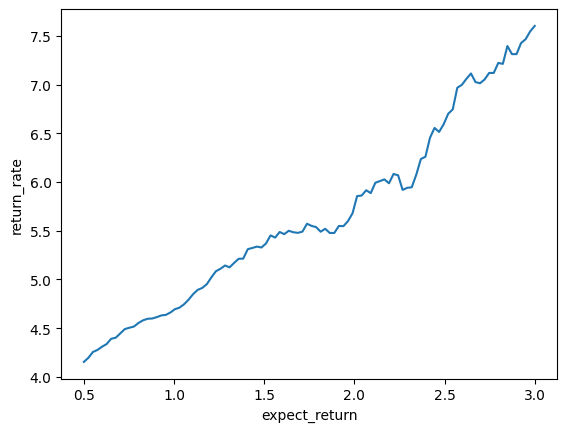

In [ ]:
# 単勝をかけた場合の結果を取得し、プロットに出力
result_tansho = CreateModel.calc_tansho(evaluation_df, n_bet=1)
sns.lineplot(result_tansho, x='expect_return', y='return_rate')
display(result_tansho.sort_values("return_rate", ascending=False))

In [ ]:
# 複勝をかけた場合の結果を取得し、プロットに出力
result_fukusho =  CreateModel.calc_fukusho(evaluation_df, return_df, n_bet=1)
sns.lineplot(result_fukusho, x='expect_return', y='return_rate')
display(result_fukusho.sort_values("return_rate", ascending=False))

In [ ]:
# 馬連をかけた場合の結果を取得し、プロットに出力
result_umaren = CreateModel.calc_ren(evaluation_df,
    return_df,
    main=1,
    sub=4,
    other=0,
    kensyu="umaren",
    target_rank=[1, 2],
    target_n_horse=2)
sns.lineplot(result_umaren, x='expect_return', y='return_rate')

In [ ]:
# 三連複をかけた場合の結果を取得し、プロットに出力
result_sanrenpuku = CreateModel.calc_ren(evaluation_df,
    return_df,
    main=1,
    sub=4,
    other=7,
    kensyu="sanrenpuku",
    target_rank=[1, 2, 3],
    target_n_horse=3)
sns.lineplot(result_sanrenpuku, x='expect_return', y='return_rate')
display(result_sanrenpuku.sort_values("return_rate", ascending=False).head(50))

# 5. 当日予想

## 5.1. 対象レースの予測

In [7]:
%autoreload

In [3]:
#processorを更新
results_df, horse_results_df = HorseResultsProcessor._preprocess(LocalPaths.TARGET_TODAY_HORSE_RESULTS_PATH)
jockey_df = SupporterProcessor._preprocess(folder_path=LocalPaths.JOCKEY_DIR,
    kind="jockey")
trainer_df = SupporterProcessor._preprocess(folder_path=LocalPaths.TRAINER_DIR,
    kind="trainer")
sir_df = SupporterProcessor._preprocess(folder_path=LocalPaths.SIR_DIR,
    kind="sir")
bms_df = SupporterProcessor._preprocess(folder_path=LocalPaths.BMS_DIR,
    kind="bms")
train_hanro_df = HorseTrainProcessor._preprocess_hanro(LocalPaths.TARGET_TODAY_TRAIN_HANRO_PATH)
train_wood_df = HorseTrainProcessor._preprocess_wood(LocalPaths.TARGET_TODAY_TRAIN_WOOD_PATH)

#スピード、上り指数、3ハロン前タイム指数を作成
SpeedIndexProcessor.calc_ground_index(horse_results_df,"time")
speed_index_processor = SpeedIndexProcessor.calc_speed_index(results_df,horse_results_df,"time")
SpeedIndexProcessor.calc_ground_index(horse_results_df,"agari")
agari_index_processor = SpeedIndexProcessor.calc_speed_index(results_df,horse_results_df,"agari")
SpeedIndexProcessor.calc_ground_index(horse_results_df,"ten_3f_time")
ten_3f_time_index_processor = SpeedIndexProcessor.calc_speed_index(results_df,horse_results_df,"ten_3f_time")

In [5]:
#モデルをロード
model_time = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_time.h5')
model_agari = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_agari.h5')
model_pci = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_pci.h5')
model_first = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_first_corner_score.h5')
model_third = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_third_corner_score.h5')
model_final = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_final_corner_score.h5')
model_ten_3f = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_ten_3f_time.h5')
model_ave_1f = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_ave_1f_time.h5')
model_leg = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_leg_quality.h5')
model_correction_2 = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_correction_2.h5')
model_speed_index = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_time_index.h5')
model_agari_index = KeibaAIFactory.load_kaiki('models/20250928/20250927_turf_agari_index.h5')
model = KeibaAIFactory.load('models/20250928/20250928_rank_turf.h5')

In [6]:
# Xにログイン
X_API_KEY = os.environ.get('X_API_KEY')
X_API_SECRET_KEY = os.environ.get('X_API_SECRET_KEY')
X_ACCESS_TOKEN = os.environ.get('X_ACCESS_TOKEN')
X_ACCESS_TOKEN_SECRET = os.environ.get('X_ACCESS_TOKEN_SECRET')
X_BEARER_TOKEN = os.environ.get('X_BEARER_TOKEN')

client_x = PostNoteX.login_x(X_API_KEY, X_API_SECRET_KEY, X_ACCESS_TOKEN, X_ACCESS_TOKEN_SECRET, X_BEARER_TOKEN)

認証に成功しました。


In [46]:
%autoreload

In [ ]:
# 出馬表を取得
ground_state = "良"
in_out = None
shutsuba_df = ShutsubaProcessor.preprocess(LocalPaths.TARGET_SHUTHUBA_PATH, in_out, ground_state)

# 日付、レースIDを取得を取得
race_id = shutsuba_df["race_id_new"][0]
today = "20250928"

In [53]:
# 出馬表にJRDBデータをマージ
shutsuba_df = shutsuba_df.merge(
    idm_index_df,on=['race_id_horse'],how="left").merge(
    jockey_index_df,on=['race_id_horse'],how="left").merge(
    info_index_df,on=['race_id_horse'],how="left").merge(
    total_index_df,on=['race_id_horse'],how="left").merge(
    popular_index_df,on=['race_id_horse'],how="left").merge(
    stable_index_df,on=['race_id_horse'],how="left").merge(
    gekiso_index_df,on=['race_id_horse'],how="left").merge(
    ten_index_df,on=['race_id_horse'],how="left").merge(
    pace_index_df,on=['race_id_horse'],how="left").merge(
    agari_index_df,on=['race_id_horse'],how="left").merge(
    position_index_df,on=['race_id_horse'],how="left").merge(
    manken_index_df,on=['race_id_horse'],how="left").merge(
    start_index_df,on=['race_id_horse'],how="left").merge(
    oikiri_index_df,on=['race_id_horse'],how="left").merge(
    shiagari_index_df,on=['race_id_horse'],how="left").merge(
    gaikyu_df,on=['race_id_horse'],how="left")

In [54]:
#天候情報の取得
today_weather_df = WeatherResultsProcessor._preprocess_today(race_id,today)

# 学習母集団の作成
population_df = CreatePopulationProcessor._preprocess_today(
    file_path=LocalPaths.TODAY_POPULATION_PATH)

# テーブルのマージ
shutuba_data_merger = DataMerger(
    population_df,
    shutsuba_df,
    horse_results_df,
    jockey_df,
    trainer_df,
    sir_df,
    bms_df,
    train_hanro_df,
    train_wood_df,
    speed_index_processor,
    agari_index_processor,
    ten_3f_time_index_processor,
    today_weather_df,
    Master.TARGET_COLS_MEAN,
    Master.TARGET_COLS_MAX,
    Master.TARGET_COLS_MIN,
    Master.TARGET_COLS_SIZE,
    Master.GROUP_COLS
)
shutuba_data_merger.merge()

# 連対率、勝率を集計しマージする。
jockey_tariner_df = shutuba_data_merger._merge_win_place_rates_today(results_df, shutsuba_df)
shutuba_data_merger._population_df = shutuba_data_merger._population_df.merge(jockey_tariner_df,on=["horse_name","jockey_name"],how="left")

separating horse results by date


100%|██████████| 1/1 [00:00<00:00, 30.63it/s]


merging train_hanro


100%|██████████| 1/1 [00:00<00:00, 69.57it/s]


merging train_wood


100%|██████████| 1/1 [00:00<00:00, 111.00it/s]


merging horse_results


100%|██████████| 1/1 [00:00<00:00,  3.79it/s]


In [55]:
# 各特徴量のワンホットエンコーディングを行う。
pre_feature_enginnering = FeatureEngineering(shutuba_data_merger._population_df)\
    .encode_race_type()\
    .encode_sex()\
    .encode_umaban()\
    .encode_in_out()\
    .encode_ground_state()\
    .encode_wakuban()\
    .encode_kaisai()\
    .encode_blinker()\
    .encode_n_horses()\
    .encode_box_category()\
    .encode_weather()\
    .encode_train_course()\
    .encode_class()\
    .other_leg_quality()\
    .encode_leg_quality()\
    .encode_gear()\
    .encode_course_len()\
    .encode_dtype()

In [56]:
# 回帰モデルの予測結果を追加
featured_data = TrainKeras.prepare_featured_data(
  pre_feature_enginnering,
  model_time, model_agari, model_pci, model_first, model_third, model_final,
  model_ten_3f, model_ave_1f, model_leg, model_correction_2, model_speed_index, model_agari_index
)

1/1 [==============================] - 0s 23ms/step


In [57]:
# テストデータの予測
evaluation_df = TrainKeras.predict_horse_probabilities(featured_data, model)
display(evaluation_df)

3/3 [==============================] - 0s 3ms/step


,race_id_new,horse_name,pred,odds,umaban
6,2025092809040909,カエルム,0.141597,12.8,7
7,2025092809040909,ウインデイジー,0.121689,11.9,8
5,2025092809040909,ライフセービング,0.115323,11.5,6
2,2025092809040909,ダノンシーマ,0.114681,1.3,3
3,2025092809040909,サークルオブジョイ,0.104547,18.7,4
9,2025092809040909,ローレルオーブ,0.086542,13.2,10
11,2025092809040909,パンデアスカル,0.083474,14.7,12
8,2025092809040909,パーサヴィアランス,0.068417,61.5,9
4,2025092809040909,フィデリオグリーン,0.060867,88.5,5
0,2025092809040909,デルマグレムリン,0.046360,43.4,1


## 5.2. note、Xへの予想投稿

In [58]:
# 推奨馬の印
hyouka_1 = "◎ "
hyouka_2 = "〇 "
hyouka_3 = "▲  "
hyouka_4 = "△ "

# 提供馬の選出
yosou = [
    f"{hyouka_1}{evaluation_df['umaban'].iloc[0]}: " + f"{evaluation_df['horse_name'].iloc[0]}",
    f"{hyouka_2}{evaluation_df['umaban'].iloc[1]}: " + f"{evaluation_df['horse_name'].iloc[1]}",
    f"{hyouka_3}{evaluation_df['umaban'].iloc[2]}: " + f"{evaluation_df['horse_name'].iloc[2]}",
    f"{hyouka_3}{evaluation_df['umaban'].iloc[3]}: " + f"{evaluation_df['horse_name'].iloc[3]}",
    f"{hyouka_4}{evaluation_df['umaban'].iloc[4]}: " + f"{evaluation_df['horse_name'].iloc[4]}",
    f"{hyouka_4}{evaluation_df['umaban'].iloc[5]}: " + f"{evaluation_df['horse_name'].iloc[5]}",
    f"{hyouka_4}{evaluation_df['umaban'].iloc[6]}: " + f"{evaluation_df['horse_name'].iloc[6]}",
]

# 買い目の選定
kaime = [
    "単勝: 7,8",
    "馬連: 7-8",
    "ワイド: 7-8",
    "三連複: 7,8-3,6,7,8-3,4,6,7,8,10,12", 
]
kaikata = "単勝、ワイド、三連複"

In [59]:
# noteへの投稿
NOTE_E_MAIL = os.environ.get('NOTE_E_MAIL')
NOTE_PASSWORD = os.environ.get('NOTE_PASSWORD')

kaisai, race_num, race_name, race_type, course_len = PostNoteX.race_result_processing(today, shutuba_data_merger)
content = PostNoteX.content_text(yosou, kaime, kaikata)
title = f"{kaisai}" + f"{race_num}R " + f"{race_name} " + f"{race_type}" + f"{course_len}m"  + "\n"
note_url = PostNoteX.post_to_note(NOTE_E_MAIL, NOTE_PASSWORD, title, content, None)

hash_tag = f"#ぽかにゃん予想 #競馬 #競馬予想 #無料予想 #中央競馬 #{kaisai} #{race_num}R #{kaisai}{race_num}R"
print(hash_tag)

1. noteにログイン中...
2. 記事を作成中...
記事作成成功！ID: 127772046
4. 記事を下書き保存中...
記事の下書き保存成功！

✅ 投稿完了！
記事URL: https://note.com/keiba_ai_poca/n/nc8f3ae119cca
#ぽかにゃん予想 #競馬 #競馬予想 #無料予想 #中央競馬 #阪神 #9R #阪神9R


In [60]:
# Xへ自動投稿
message = (
    f"{kaisai}" + f"{race_num}R " + f"{race_name} " + f"{race_type}" + f"{course_len}m"
    "\n\n"  # 空行
    "本日1つ目の予想提供レースです。"
    "\n"  # 空行
    "推奨馬はこちらです。無料提供ですので、当たった方はリポストいただけるとモチベになります。"
    "\n\n"  # 空行
    f"{note_url}"
    "\n\n"  # 空行
    f"{hash_tag}"
)

# 投稿する
client_x.create_tweet(text=message)
print("ツイートを投稿しました。")

ツイートを投稿しました。
